Label distribution:
true_label
positive    24160
unknown       295
negative      285
Name: count, dtype: int64
Classification Report:

              precision    recall  f1-score   support

    negative     0.5222    0.8246    0.6395        57
    positive     0.9979    0.9911    0.9945      4832

    accuracy                         0.9892      4889
   macro avg     0.7601    0.9078    0.8170      4889
weighted avg     0.9924    0.9892    0.9904      4889



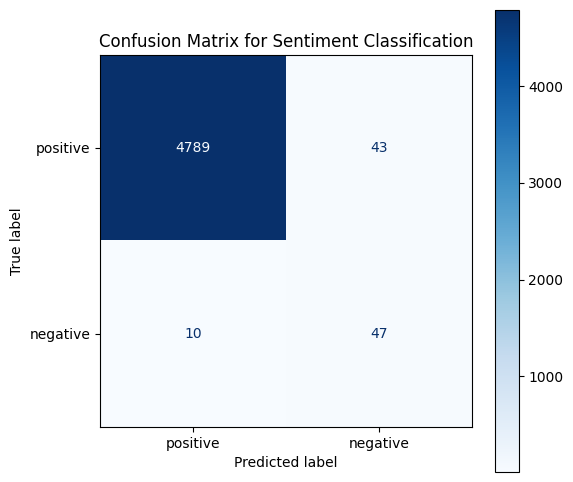


Sample false negatives:
                                                content true_label predicted
1161  despite linking a track and explaining precise...   negative  positive
1305  hi,\r\ni was not very happy with the ideas. th...   negative  positive
1431   correct but i had to review and redo many things   negative  positive
1806                                        great work!   negative  positive
2545  extremely overprice for limited level of capab...   negative  positive
2601  won’t refund my money his work is horrible had...   negative  positive
3777  frankly, was just testing out the service. low...   negative  positive
4285                                 below expectations   negative  positive
4567  i cannot see what was doing, really dissatisfi...   negative  positive
4865                                    horrible. avoid   negative  positive

Adjusted label distribution:
adjusted_label
positive    24325
negative      415
Name: count, dtype: int64


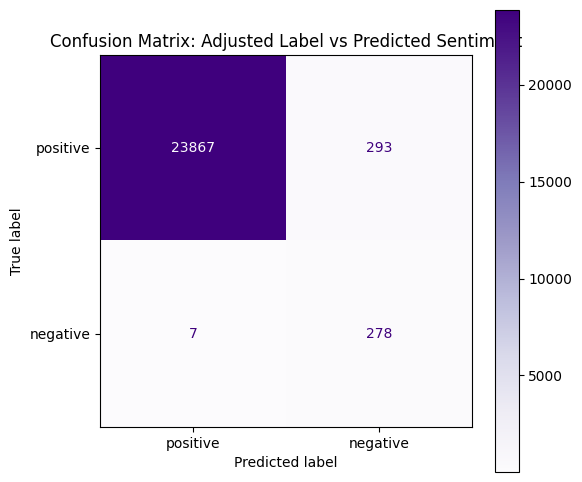

Results saved to sentiment_output_adjusted.csv.


In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('reviews_cleaned.csv')

def preprocess(text):
    return str(text).lower().strip()

df['clean_content'] = df['CONTENT'].apply(preprocess)

def rating_to_label(rating):
    if rating >= 4:
        return 'positive'
    elif rating <= 2:
        return 'negative'
    else:
        return 'unknown'  # This is for RATING = 3

df['true_label'] = df['RATING'].apply(rating_to_label)

print("Label distribution:")
print(df['true_label'].value_counts())

df_filtered = df[df['true_label'] != 'unknown'].copy()

X = df_filtered['clean_content']
y = df_filtered['true_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_vec, y_train)

y_probs = model.predict_proba(X_test_vec)

threshold = 0.4  

pos_index = list(model.classes_).index('positive')

y_pred = ['positive' if prob[pos_index] >= threshold else 'negative' for prob in y_probs]

report = classification_report(y_test, y_pred, digits=4)
print("Classification Report:\n")
print(report)

cm = confusion_matrix(y_test, y_pred, labels=['positive', 'negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix for Sentiment Classification")
plt.show()

y_test_series = pd.Series(y_test).reset_index(drop=True)
X_test_series = X_test.reset_index(drop=True)

false_negatives = pd.DataFrame({
    'content': X_test_series,
    'true_label': y_test_series,
    'predicted': y_pred
})

false_negatives = false_negatives[(false_negatives['true_label'] == 'negative') & (false_negatives['predicted'] == 'positive')]
print("\nSample false negatives:")
print(false_negatives.head(10))

X_all_vec = vectorizer.transform(df['clean_content'])
df['predicted_sentiment'] = model.predict(X_all_vec)

df['adjusted_label'] = df.apply(
    lambda row: row['predicted_sentiment'] if row['true_label'] == 'unknown' else row['true_label'],
    axis=1
)

print("\nAdjusted label distribution:")
print(df['adjusted_label'].value_counts())


df_eval = df[df['true_label'] != 'unknown'].copy()

cm_adjusted = confusion_matrix(df_eval['adjusted_label'], df_eval['predicted_sentiment'], labels=['positive', 'negative'])
disp_adjusted = ConfusionMatrixDisplay(confusion_matrix=cm_adjusted, display_labels=['positive', 'negative'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_adjusted.plot(cmap='Purples', ax=ax, values_format='d')
plt.title("Confusion Matrix: Adjusted Label vs Predicted Sentiment")
plt.show()

df.to_csv('sentiment_output_adjusted.csv', index=False)
print("Results saved to sentiment_output_adjusted.csv.")


In [2]:
# === Calculate and print accuracy percentage ===

# For evaluation on test set (standard accuracy)
accuracy = (np.array(y_pred) == np.array(y_test)).mean()
print(f"Model accuracy on test set: {accuracy:.2%}")

# For adjusted labels (if you want to check adjusted_label vs predicted_sentiment)
# This only makes sense for rows where true_label != 'unknown'
adjusted_accuracy = (df_eval['adjusted_label'] == df_eval['predicted_sentiment']).mean()
print(f"Adjusted label vs predicted sentiment accuracy: {adjusted_accuracy:.2%}")


Model accuracy on test set: 98.92%
Adjusted label vs predicted sentiment accuracy: 98.77%


In [3]:
print("Ratings distribution in full dataset:")
print(df['RATING'].value_counts())

print("\nLabel distribution after filtering:")
print(df_filtered['true_label'].value_counts())


Ratings distribution in full dataset:
RATING
5    22741
4     1419
3      295
1      168
2      117
Name: count, dtype: int64

Label distribution after filtering:
true_label
positive    24160
negative      285
Name: count, dtype: int64


In [4]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'word': feature_names,
    'coefficient': coefficients
})

coef_df_sorted = coef_df.sort_values(by='coefficient', ascending=False)

# Top positive words
print("Top positive words:")
print(coef_df_sorted.head(20))

# Top negative words
print("\nTop negative words:")
print(coef_df_sorted.tail(20))


Top positive words:
             word  coefficient
5143        great     7.072197
691       amazing     4.521886
5511       highly     3.961290
4108      exactly     3.920522
13166        will     3.701895
763           and     3.690745
4126    excellent     3.665194
11973       thank     3.634382
5074         good     3.589980
6128           is     3.547542
13197        with     3.482841
6311          job     3.369953
1524         best     3.333459
9685    recommend     3.306444
666        always     3.250608
12797        very     3.085668
3117   definitely     3.082867
8670      perfect     2.883700
4395         fast     2.849479
13086        well     2.802121

Top negative words:
                         word  coefficient
11943                terrible    -3.289088
8345                       or    -3.331547
10504                    scam    -3.337143
24     1111111111111111111111    -3.472691
4522                     fine    -3.481240
6661                   lacked    -3.521880
3512   